# 1. 判断模型是否认识了三类人

##  1.1 宏观分析：换血分析


📥 正在嗅探并加载三大宇宙数据 (无 Mock，全真实数据)...
🔍 检测到 ours 模型输出了原生的 'c_uplift_pred'，已采用 MTL 自身预测！

🏆 [换血对账单] ours vs V1_base 全景透视 (包含独立预测C通道)
  区间  换血量  🚨净Y收益  净C代价  ours_Y增益  V1_Y增益  ours_真实C  V1_真实C  ours_预测C  V1_预测C  ours_因果效率  V1_因果效率
  0-5%   24843    0.00888  0.04717     0.01113   0.00225     0.06243   0.01526     0.05703   0.02240        0.17825      0.14727
 5-10%   53268   -0.00400 -0.00152     0.00167   0.00566     0.02301   0.02453     0.02578   0.02438        0.07250      0.23093
10-15%   62074   -0.00046 -0.00104     0.00052   0.00097     0.01293   0.01397     0.01349   0.01482        0.03985      0.06949
15-20%   66840    0.00045  0.00197     0.00044  -0.00001     0.00842   0.00645     0.00717   0.01020        0.05168     -0.00166
20-50%  363031   -0.00007 -0.00045     0.00013   0.00020     0.00165   0.00210     0.00079   0.00226        0.08044      0.09625

🎨 极简学术对比图已生成: 0418_Swapping_Delta.png

📥 正在嗅探并加载三大宇宙数据 (无 Mock，全真实数据)...
⚠️ 未检测到 'c_uplift_pred'，ours 模型将降级使用独立 C 模型的先验作为预测 C。



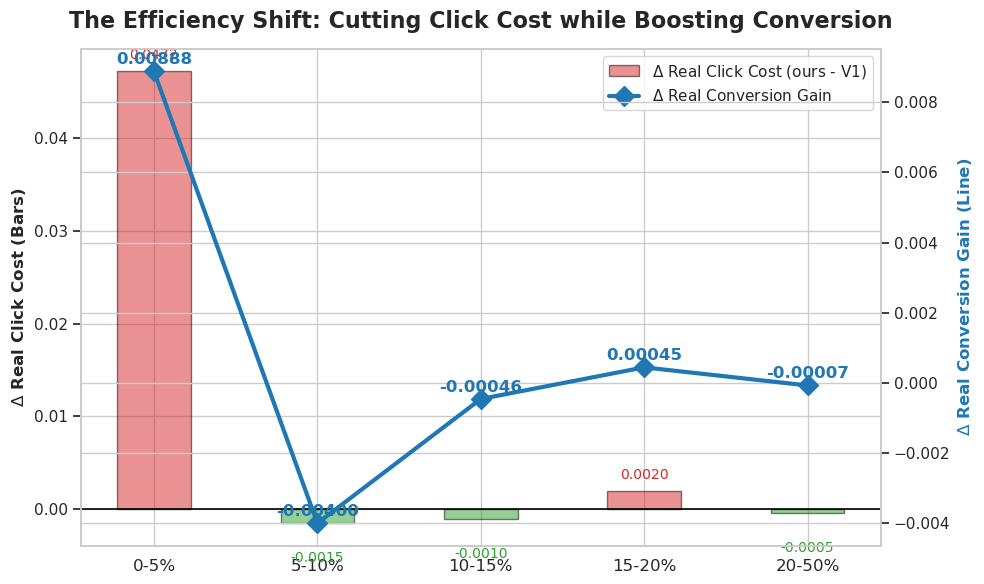

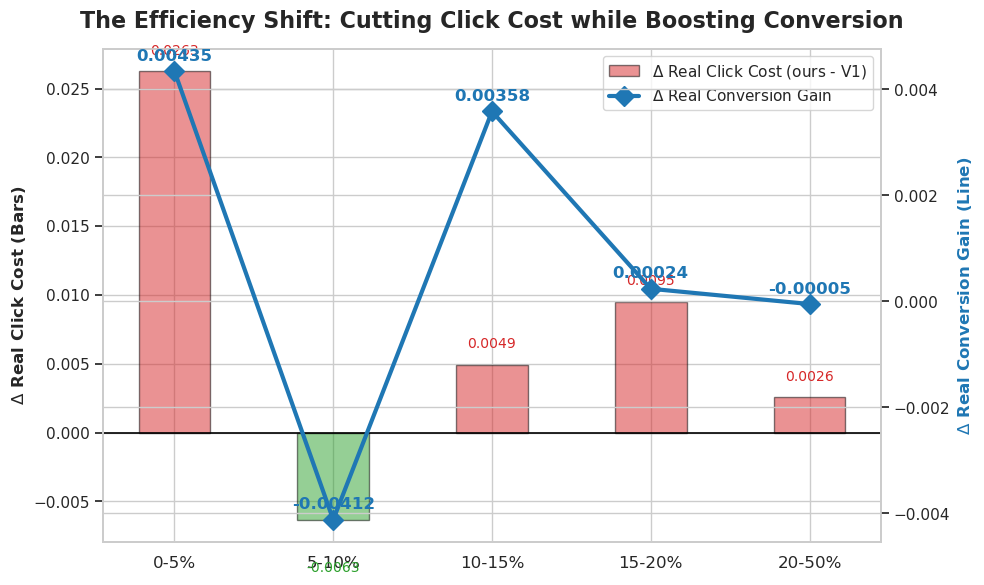

In [12]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. 核心底座：路径嗅探与分析引擎
# ==========================================
def resolve_path(pattern):
    """自动解析带 ** 通配符的路径，找到最新的 csv"""
    files = glob.glob(pattern, recursive=True)
    if not files:
        raise FileNotFoundError(f"❌ 找不到匹配的文件: {pattern}")
    return files[0]

class CausalSwappingAnalyzer:
    def __init__(self, c_pattern, v1_pattern, ours_pattern):
        print("\n📥 正在嗅探并加载三大宇宙数据 (无 Mock，全真实数据)...")
        self.df_c = pd.read_csv(resolve_path(c_pattern))
        self.df_v1 = pd.read_csv(resolve_path(v1_pattern))
        self.df_ours = pd.read_csv(resolve_path(ours_pattern))
        
        # 物理截断：把独立 C 模型的负概率置为0，作为全局的基准先验
        c_prior_referee = np.clip(self.df_c['y1_prob'] - self.df_c['y0_prob'], 0, None)
        
        # 构建事实宽表
        self.master = pd.DataFrame({
            't': self.df_c['t'],
            'y_true': self.df_c['y_true'],
            'c_true': self.df_c['c_true'],
            'v1_score': self.df_v1['uplift_pred'],
            'ours_score': self.df_ours['uplift_pred'],
            # V1 没有预测 C 的能力，用裁判先验代表它的点击偏好幻觉
            'v1_pred_c': c_prior_referee 
        })
        
        # 🌟 核心修正：智能嗅探 ours 模型是否有自带的预测 C
        if 'c_uplift_pred' in self.df_ours.columns:
            print("🔍 检测到 ours 模型输出了原生的 'c_uplift_pred'，已采用 MTL 自身预测！")
            self.master['ours_pred_c'] = self.df_ours['c_uplift_pred']
        else:
            print("⚠️ 未检测到 'c_uplift_pred'，ours 模型将降级使用独立 C 模型的先验作为预测 C。")
            self.master['ours_pred_c'] = c_prior_referee

        # 计算全局排名百分位
        self.master['v1_pos'] = self.master['v1_score'].rank(pct=True, ascending=False)
        self.master['ours_pos'] = self.master['ours_score'].rank(pct=True, ascending=False)

    def _get_stats(self, indices, pred_c_col):
        """核心算子：提取 Y增益、真实C增益、各自的预测C预期"""
        if len(indices) == 0:
            return 0.0, 0.0, 0.0, 0.0
            
        group = self.master.loc[indices]
        t1, t0 = group[group['t'] == 1], group[group['t'] == 0]
        
        y_lift = (t1['y_true'].mean() if len(t1)>0 else 0) - (t0['y_true'].mean() if len(t0)>0 else 0)
        c_lift = (t1['c_true'].mean() if len(t1)>0 else 0) - (t0['c_true'].mean() if len(t0)>0 else 0)
        pred_c = group[pred_c_col].mean() # 提取各自网络当时的预测 C
        
        # 因果效率
        eff = y_lift / (c_lift + 1e-6) if c_lift > 0 else 0.0
        return y_lift, c_lift, pred_c, eff

    def analyze_swapping(self, start_pct, end_pct):
        """对比指定区间内的换血情况"""
        v1_set = set(self.master[(self.master['v1_pos'] > start_pct) & (self.master['v1_pos'] <= end_pct)].index)
        ours_set = set(self.master[(self.master['ours_pos'] > start_pct) & (self.master['ours_pos'] <= end_pct)].index)
        
        ours_promoted = list(ours_set - v1_set)  # ours提拔的人
        v1_retained = list(v1_set - ours_set)    # V1坚守的人
        
        # 分别传入对应的 预测C 列名
        ours_y, ours_c, ours_pc, ours_eff = self._get_stats(ours_promoted, 'ours_pred_c')
        v1_y, v1_c, v1_pc, v1_eff = self._get_stats(v1_retained, 'v1_pred_c')
        
        return {
            '区间': f"{start_pct*100:.0f}-{end_pct*100:.0f}%",
            '换血量': len(ours_promoted),
            'ours_Y增益': ours_y,  'V1_Y增益': v1_y,  '🚨净Y收益': ours_y - v1_y,
            'ours_真实C': ours_c,  'V1_真实C': v1_c,  '净C代价': ours_c - v1_c,
            'ours_预测C': ours_pc, 'V1_预测C': v1_pc,
            'ours_因果效率': ours_eff, 'V1_因果效率': v1_eff
        }

# ==========================================
# 2. 核心画图引擎：高级学术精简版
# ==========================================
def plot_academic_swapping(df, output_path="0418_Swapping_Delta.png"):
    """
    极简学术画图：只画 $\Delta Y$ 和 $\Delta C$
    直击灵魂：证明 ours 降了点击代价，赚了转化
    """
    sns.set_theme(style="whitegrid")
    fig, ax1 = plt.subplots(1, 1, figsize=(10, 6))
    
    bins = df['区间'].tolist()
    x = np.arange(len(bins))
    
    net_y = df['🚨净Y收益'].values
    net_c = df['净C代价'].values
    
    # 画 $\Delta C$ (背景柱子)：绿色代表成本降了，红色代表成本升了
    c_colors = ['#2ca02c' if val < 0 else '#d62728' for val in net_c]
    bars = ax1.bar(x, net_c, color=c_colors, alpha=0.5, edgecolor='black', width=0.45, label='$\Delta$ Real Click Cost (ours - V1)')
    
    ax1.axhline(0, color='black', linewidth=1.2)
    ax1.set_ylabel("$\Delta$ Real Click Cost (Bars)", fontsize=12, fontweight='bold')
    ax1.set_xticks(x)
    ax1.set_xticklabels(bins, fontsize=12)
    
    # 标出柱子数值
    for i, bar in enumerate(bars):
        yval = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2, yval + (0.001 if yval > 0 else -0.003), 
                 f'{yval:.4f}', ha='center', va='bottom' if yval > 0 else 'top', fontsize=10, color=c_colors[i])

    # 画 $\Delta Y$ (前景折线)：蓝色折线
    ax1_twin = ax1.twinx()
    ax1_twin.plot(x, net_y, marker='D', markersize=10, color='#1f77b4', linewidth=3, label='$\Delta$ Real Conversion Gain')
    ax1_twin.set_ylabel("$\Delta$ Real Conversion Gain (Line)", fontsize=12, fontweight='bold', color='#1f77b4')
    
    for i, val in enumerate(net_y):
        ax1_twin.text(x[i], val + 0.0002, f'{val:.5f}', ha='center', fontweight='bold', color='#1f77b4')

    # 合并图例
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax1_twin.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
    
    plt.title("The Efficiency Shift: Cutting Click Cost while Boosting Conversion", fontsize=16, fontweight='bold', pad=15)
    plt.tight_layout()
    plt.savefig(output_path, dpi=300)
    print(f"\n🎨 极简学术对比图已生成: {output_path}")


# ==========================================
# 3. 启动执行模块
# ==========================================
if __name__ == "__main__":
    # 配置绝对真实的路径
    C_PATH  = "./results/criteo/train_c/TARNET/c_v1_base/**/test_dist.csv"
    V1_PATH = "./results/criteo/train_y/TARNET/y_v1_base/**/test_dist.csv"
    ours_PATH = "./results/criteo/train_y/ECUP/**/test_dist.csv" # 替换为你要测的模型 (如 ECUP, V8 等)
    
    analyzer = CausalSwappingAnalyzer(C_PATH, V1_PATH, ours_PATH)
    
    # 细致切割冲突区
    bins = [(0.0, 0.05), (0.05, 0.10), (0.10, 0.15), (0.15, 0.20), (0.20, 0.50)]
    results = [analyzer.analyze_swapping(s, e) for s, e in bins]
    df_report = pd.DataFrame(results)
    
    # 终端打印排版 (防乱码、防换行)
    pd.set_option('display.unicode.east_asian_width', True) 
    pd.set_option('display.unicode.ambiguous_as_wide', True)
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', 1500)
    pd.set_option('display.float_format', '{:.5f}'.format)
    
    print("\n" + "="*160)
    print("🏆 [换血对账单] ours vs V1_base 全景透视 (包含独立预测C通道)")
    print("="*160)
    
    # 按逻辑分组显示，一目了然
    display_cols = [
        '区间', '换血量', '🚨净Y收益', '净C代价',
        'ours_Y增益', 'V1_Y增益', 
        'ours_真实C', 'V1_真实C', 
        'ours_预测C', 'V1_预测C',
        'ours_因果效率', 'V1_因果效率'
    ]
    print(df_report[display_cols].to_string(index=False))
    print("="*160)
    
    # 生成图表
    plot_academic_swapping(df_report)

# ==========================================
# 3. 启动执行模块
# ==========================================
if __name__ == "__main__":
    # 配置绝对真实的路径
    C_PATH  = "./results/criteo/train_c/TARNET/c_v1_base/**/test_dist.csv"
    V1_PATH = "./results/criteo/train_y/TARNET/y_v1_base/**/test_dist.csv"
    ours_PATH = "./results/criteo/train_y/TARNET/y_v8_s5/**/test_dist.csv" 
    
    analyzer = CausalSwappingAnalyzer(C_PATH, V1_PATH, ours_PATH)
    
    # 细致切割冲突区
    bins = [(0.0, 0.05), (0.05, 0.10), (0.10, 0.15), (0.15, 0.20), (0.20, 0.50)]
    results = [analyzer.analyze_swapping(s, e) for s, e in bins]
    df_report = pd.DataFrame(results)
    
    # 终端打印排版 (防乱码、防换行)
    pd.set_option('display.unicode.east_asian_width', True) 
    pd.set_option('display.unicode.ambiguous_as_wide', True)
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', 1500)
    pd.set_option('display.float_format', '{:.5f}'.format)
    
    print("\n" + "="*160)
    print("🏆 [换血对账单] ours vs V1_base 全景透视 (包含真实C与预测C)")
    print("="*160)
    # 按逻辑分组显示，一目了然
    display_cols = [
        '区间', '换血量', '🚨净Y收益', '净C代价',
        'ours_Y增益', 'V1_Y增益', 
        'ours_真实C', 'V1_真实C', 
        'ours_预测C', 'V1_预测C',
        'ours_因果效率', 'V1_因果效率'
    ]
    print(df_report[display_cols].to_string(index=False))
    print("="*160)
    
    # 生成图表
    plot_academic_swapping(df_report)


📥 正在嗅探并加载三大宇宙数据 (无 Mock，全真实数据)...



🏆 [换血对账单] ours vs V1_base 全景透视 (包含真实C与预测C)
  区间  换血量  🚨净Y收益  净C代价  ours_Y增益  V1_Y增益  ours_真实C  V1_真实C  ours_预测C  V1_预测C  ours_因果效率  V1_因果效率
  0-5%    8026    0.02428 -0.01196     0.02586   0.00158     0.03505   0.04701     0.08922   0.03826        0.73783      0.03352
 5-10%   18579   -0.00908  0.00306     0.00244   0.01152     0.03792   0.03486     0.03227   0.04388        0.06440      0.33042
10-15%   21918   -0.00029  0.00995     0.00145   0.00174     0.03551   0.02556     0.02315   0.02039        0.04080      0.06797
15-20%   17420   -0.00044 -0.00340    -0.00007   0.00037     0.01630   0.01970     0.01827   0.01941       -0.00428      0.01861
20-50%  387325    0.00013  0.00317     0.00018   0.00005     0.00359   0.00042     0.00364   0.00055        0.04939      0.12304


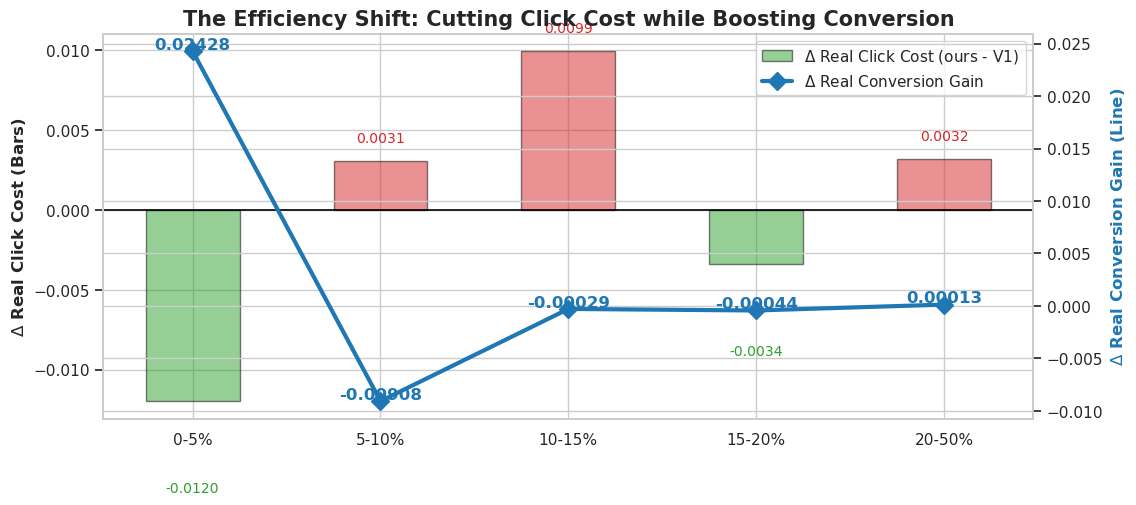

In [5]:
# ==========================================
# 3. 启动执行模块
# ==========================================
if __name__ == "__main__":
    # 配置绝对真实的路径
    C_PATH  = "./results/criteo/train_c/TARNET/c_v1_base/**/test_dist.csv"
    V1_PATH = "./results/criteo/train_y/TARNET/y_v1_base/**/test_dist.csv"
    ours_PATH = "./results/criteo/train_y/TARNET/y_v8_s1_t10/**/test_dist.csv" 
    
    analyzer = CausalSwappingAnalyzer(C_PATH, V1_PATH, ours_PATH)
    
    # 细致切割冲突区
    bins = [(0.0, 0.05), (0.05, 0.10), (0.10, 0.15), (0.15, 0.20), (0.20, 0.50)]
    results = [analyzer.analyze_swapping(s, e) for s, e in bins]
    df_report = pd.DataFrame(results)
    
    # 终端打印排版 (防乱码、防换行)
    pd.set_option('display.unicode.east_asian_width', True) 
    pd.set_option('display.unicode.ambiguous_as_wide', True)
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', 1500)
    pd.set_option('display.float_format', '{:.5f}'.format)
    
    print("\n" + "="*160)
    print("🏆 [换血对账单] ours vs V1_base 全景透视 (包含真实C与预测C)")
    print("="*160)
    # 按逻辑分组显示，一目了然
    display_cols = [
        '区间', '换血量', '🚨净Y收益', '净C代价',
        'ours_Y增益', 'V1_Y增益', 
        'ours_真实C', 'V1_真实C', 
        'ours_预测C', 'V1_预测C',
        'ours_因果效率', 'V1_因果效率'
    ]
    print(df_report[display_cols].to_string(index=False))
    print("="*160)
    
    # 生成图表
    plot_academic_swapping(df_report)


📥 正在嗅探并加载三大宇宙数据 (无 Mock，全真实数据)...



🏆 [换血对账单] ours vs V1_base 全景透视 (包含真实C与预测C)
  区间  换血量  🚨净Y收益  净C代价  ours_Y增益  V1_Y增益  ours_真实C  V1_真实C  ours_预测C  V1_预测C  ours_因果效率  V1_因果效率
  0-5%   11174    0.01109 -0.06180     0.01556   0.00448     0.02918   0.09098     0.05786   0.06531        0.53338      0.04921
 5-10%   18501   -0.00531  0.04246     0.00435   0.00966     0.08016   0.03769     0.06075   0.04458        0.05432      0.25639
10-15%   19608   -0.00008  0.01771     0.00180   0.00188     0.04762   0.02991     0.05271   0.02916        0.03771      0.06277
15-20%   18461    0.00175  0.00719     0.00071  -0.00103     0.01943   0.01224     0.02636   0.01920        0.03679     -0.08432
20-50%  388929    0.00001  0.00226     0.00012   0.00011     0.00320   0.00094     0.00310   0.00139        0.03820      0.12102


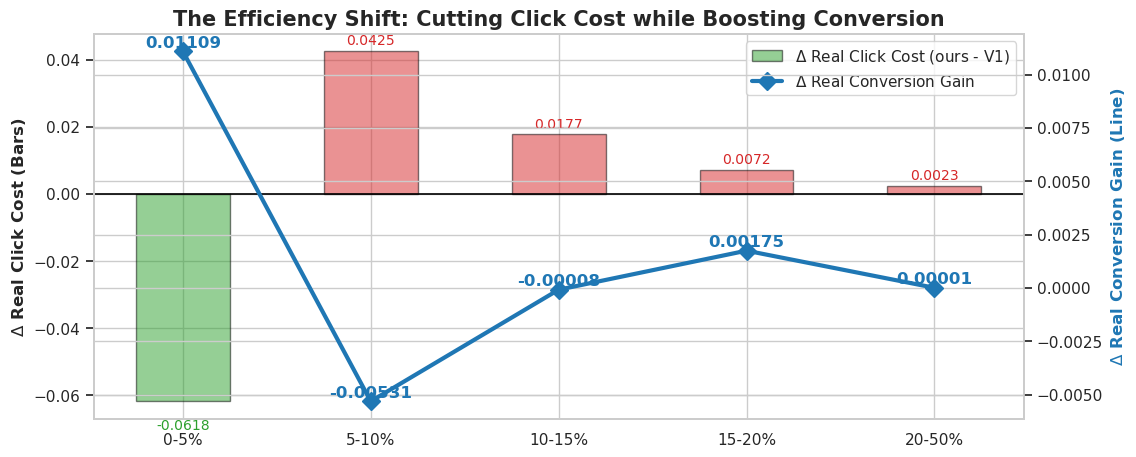

In [6]:
# ==========================================
# 3. 启动执行模块
# ==========================================
if __name__ == "__main__":
    # 配置绝对真实的路径
    C_PATH  = "./results/criteo/train_c/TARNET/c_v1_base/**/test_dist.csv"
    V1_PATH = "./results/criteo/train_y/TARNET/y_v1_base/**/test_dist.csv"
    ours_PATH = "./results/criteo/train_y/TARNET/y_v7_soft_top5/**/test_dist.csv" 
    
    analyzer = CausalSwappingAnalyzer(C_PATH, V1_PATH, ours_PATH)
    
    # 细致切割冲突区
    bins = [(0.0, 0.05), (0.05, 0.10), (0.10, 0.15), (0.15, 0.20), (0.20, 0.50)]
    results = [analyzer.analyze_swapping(s, e) for s, e in bins]
    df_report = pd.DataFrame(results)
    
    # 终端打印排版 (防乱码、防换行)
    pd.set_option('display.unicode.east_asian_width', True) 
    pd.set_option('display.unicode.ambiguous_as_wide', True)
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', 1500)
    pd.set_option('display.float_format', '{:.5f}'.format)
    
    print("\n" + "="*160)
    print("🏆 [换血对账单] ours vs V1_base 全景透视 (包含真实C与预测C)")
    print("="*160)
    # 按逻辑分组显示，一目了然
    display_cols = [
        '区间', '换血量', '🚨净Y收益', '净C代价',
        'ours_Y增益', 'V1_Y增益', 
        'ours_真实C', 'V1_真实C', 
        'ours_预测C', 'V1_预测C',
        'ours_因果效率', 'V1_因果效率'
    ]
    print(df_report[display_cols].to_string(index=False))
    print("="*160)
    
    # 生成图表
    plot_academic_swapping(df_report)


📥 正在嗅探并加载三大宇宙数据 (无 Mock，全真实数据)...
⚠️ 未检测到 'c_uplift_pred'，ours 模型将降级使用独立 C 模型的先验作为预测 C。

🏆 [换血对账单] ours vs V1_base 全景透视 (包含真实C与预测C)
  区间  换血量  🚨净Y收益  净C代价  ours_Y增益  V1_Y增益  ours_真实C  V1_真实C  ours_预测C  V1_预测C  ours_因果效率  V1_因果效率
  0-5%   11174    0.01109 -0.06180     0.01556   0.00448     0.02918   0.09098     0.05786   0.06531        0.53338      0.04921
 5-10%   18501   -0.00531  0.04246     0.00435   0.00966     0.08016   0.03769     0.06075   0.04458        0.05432      0.25639
10-15%   19608   -0.00008  0.01771     0.00180   0.00188     0.04762   0.02991     0.05271   0.02916        0.03771      0.06277
15-20%   18461    0.00175  0.00719     0.00071  -0.00103     0.01943   0.01224     0.02636   0.01920        0.03679     -0.08432
20-50%  388929    0.00001  0.00226     0.00012   0.00011     0.00320   0.00094     0.00310   0.00139        0.03820      0.12102

🎨 极简学术对比图已生成: 0418_Swapping_Delta.png


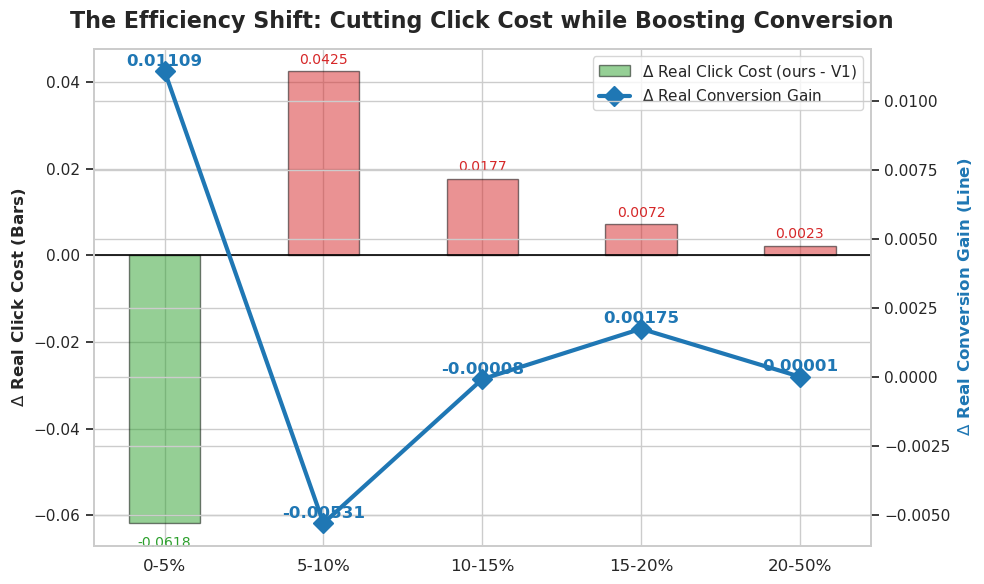

In [11]:
# ==========================================
# 3. 启动执行模块
# ==========================================
if __name__ == "__main__":
    # 配置绝对真实的路径
    C_PATH  = "./results/criteo/train_c/TARNET/c_v1_base/**/test_dist.csv"
    V1_PATH = "./results/criteo/train_y/TARNET/y_v1_base/**/test_dist.csv"
    ours_PATH = "./results/criteo/train_y/TARNET/y_v7_soft_top5/**/test_dist.csv" 
    
    analyzer = CausalSwappingAnalyzer(C_PATH, V1_PATH, ours_PATH)
    
    # 细致切割冲突区
    bins = [(0.0, 0.05), (0.05, 0.10), (0.10, 0.15), (0.15, 0.20), (0.20, 0.50)]
    results = [analyzer.analyze_swapping(s, e) for s, e in bins]
    df_report = pd.DataFrame(results)
    
    # 终端打印排版 (防乱码、防换行)
    pd.set_option('display.unicode.east_asian_width', True) 
    pd.set_option('display.unicode.ambiguous_as_wide', True)
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', 1500)
    pd.set_option('display.float_format', '{:.5f}'.format)
    
    print("\n" + "="*160)
    print("🏆 [换血对账单] ours vs V1_base 全景透视 (包含真实C与预测C)")
    print("="*160)
    # 按逻辑分组显示，一目了然
    display_cols = [
        '区间', '换血量', '🚨净Y收益', '净C代价',
        'ours_Y增益', 'V1_Y增益', 
        'ours_真实C', 'V1_真实C', 
        'ours_预测C', 'V1_预测C',
        'ours_因果效率', 'V1_因果效率'
    ]
    print(df_report[display_cols].to_string(index=False))
    print("="*160)
    
    # 生成图表
    plot_academic_swapping(df_report)


📥 正在嗅探并加载三大宇宙数据 (无 Mock，全真实数据)...


🔍 检测到 ours 模型输出了原生的 'c_uplift_pred'，已采用 MTL 自身预测！

🏆 [换血对账单] ours vs V1_base 全景透视 (包含真实C与预测C)
  区间  换血量  🚨净Y收益  净C代价  ours_Y增益  V1_Y增益  ours_真实C  V1_真实C  ours_预测C  V1_预测C  ours_因果效率  V1_因果效率
  0-5%   24843    0.00888  0.04717     0.01113   0.00225     0.06243   0.01526     0.05703   0.02240        0.17825      0.14727
 5-10%   53268   -0.00400 -0.00152     0.00167   0.00566     0.02301   0.02453     0.02578   0.02438        0.07250      0.23093
10-15%   62074   -0.00046 -0.00104     0.00052   0.00097     0.01293   0.01397     0.01349   0.01482        0.03985      0.06949
15-20%   66840    0.00045  0.00197     0.00044  -0.00001     0.00842   0.00645     0.00717   0.01020        0.05168     -0.00166
20-50%  363031   -0.00007 -0.00045     0.00013   0.00020     0.00165   0.00210     0.00079   0.00226        0.08044      0.09625

🎨 极简学术对比图已生成: 0418_Swapping_Delta.png


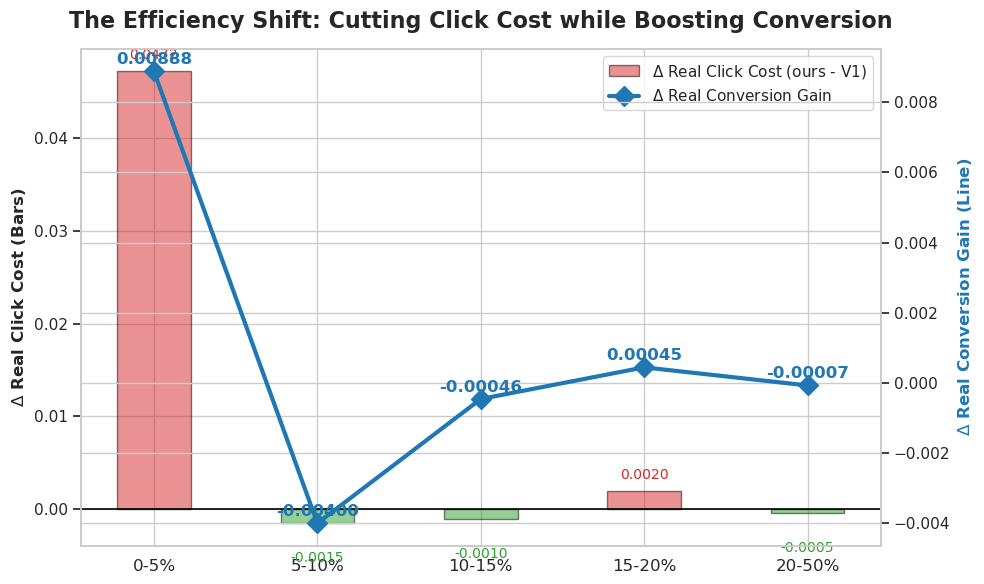

In [13]:
# ==========================================
# 3. 启动执行模块
# ==========================================
if __name__ == "__main__":
    # 配置绝对真实的路径
    C_PATH  = "./results/criteo/train_c/TARNET/c_v1_base/**/test_dist.csv"
    V1_PATH = "./results/criteo/train_y/TARNET/y_v1_base/**/test_dist.csv"
    ours_PATH = "./results/criteo/train_y/ECUP/**/**/test_dist.csv" 
    
    analyzer = CausalSwappingAnalyzer(C_PATH, V1_PATH, ours_PATH)
    
    # 细致切割冲突区
    bins = [(0.0, 0.05), (0.05, 0.10), (0.10, 0.15), (0.15, 0.20), (0.20, 0.50)]
    results = [analyzer.analyze_swapping(s, e) for s, e in bins]
    df_report = pd.DataFrame(results)
    
    # 终端打印排版 (防乱码、防换行)
    pd.set_option('display.unicode.east_asian_width', True) 
    pd.set_option('display.unicode.ambiguous_as_wide', True)
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', 1500)
    pd.set_option('display.float_format', '{:.5f}'.format)
    
    print("\n" + "="*160)
    print("🏆 [换血对账单] ours vs V1_base 全景透视 (包含真实C与预测C)")
    print("="*160)
    # 按逻辑分组显示，一目了然
    display_cols = [
        '区间', '换血量', '🚨净Y收益', '净C代价',
        'ours_Y增益', 'V1_Y增益', 
        'ours_真实C', 'V1_真实C', 
        'ours_预测C', 'V1_预测C',
        'ours_因果效率', 'V1_因果效率'
    ]
    print(df_report[display_cols].to_string(index=False))
    print("="*160)
    
    # 生成图表
    plot_academic_swapping(df_report)

In [14]:
# ==========================================
# 3. 启动执行模块
# ==========================================
if __name__ == "__main__":
    # 配置绝对真实的路径
    C_PATH  = "./results/criteo/train_c/TARNET/c_v1_base/**/test_dist.csv"
    V1_PATH = "./results/criteo/train_y/TARNET/y_v1_base/**/test_dist.csv"
    ours_PATH = "./results/criteo/train_y/MOTTO/**/**/test_dist.csv" 
    
    analyzer = CausalSwappingAnalyzer(C_PATH, V1_PATH, ours_PATH)
    
    # 细致切割冲突区
    bins = [(0.0, 0.05), (0.05, 0.10), (0.10, 0.15), (0.15, 0.20), (0.20, 0.50)]
    results = [analyzer.analyze_swapping(s, e) for s, e in bins]
    df_report = pd.DataFrame(results)
    
    # 终端打印排版 (防乱码、防换行)
    pd.set_option('display.unicode.east_asian_width', True) 
    pd.set_option('display.unicode.ambiguous_as_wide', True)
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', 1500)
    pd.set_option('display.float_format', '{:.5f}'.format)
    
    print("\n" + "="*160)
    print("🏆 [换血对账单] ours vs V1_base 全景透视 (包含真实C与预测C)")
    print("="*160)
    # 按逻辑分组显示，一目了然
    display_cols = [
        '区间', '换血量', '🚨净Y收益', '净C代价',
        'ours_Y增益', 'V1_Y增益', 
        'ours_真实C', 'V1_真实C', 
        'ours_预测C', 'V1_预测C',
        'ours_因果效率', 'V1_因果效率'
    ]
    print(df_report[display_cols].to_string(index=False))
    print("="*160)
    
    # 生成图表
    plot_academic_swapping(df_report)


📥 正在嗅探并加载三大宇宙数据 (无 Mock，全真实数据)...
⚠️ 未检测到 'c_uplift_pred'，ours 模型将降级使用独立 C 模型的先验作为预测 C。



📥 正在嗅探并加载三大宇宙数据 (无 Mock，全真实数据)...



🏆 [换血对账单] ours vs V1_base 全景透视 (包含真实C与预测C)
  区间  换血量  🚨净Y收益  净C代价  ours_Y增益  V1_Y增益  ours_真实C  V1_真实C  ours_预测C  V1_预测C  ours_因果效率  V1_因果效率
  0-5%    5353    0.02020  0.08108     0.01942  -0.00078     0.08854   0.00746     0.09382   0.02175        0.21936     -0.10384
 5-10%    9784   -0.00788 -0.02470     0.00356   0.01144     0.03591   0.06061     0.03837   0.06385        0.09901      0.18872
10-15%   15345   -0.00077 -0.00153     0.00123   0.00200     0.03089   0.03242     0.03179   0.03406        0.03967      0.06157
15-20%   17882   -0.00094  0.01454    -0.00049   0.00045     0.02690   0.01237     0.03201   0.01900       -0.01827      0.03613
20-50%  192263    0.00010  0.00249     0.00022   0.00012     0.00409   0.00160     0.00427   0.00238        0.05336      0.07507


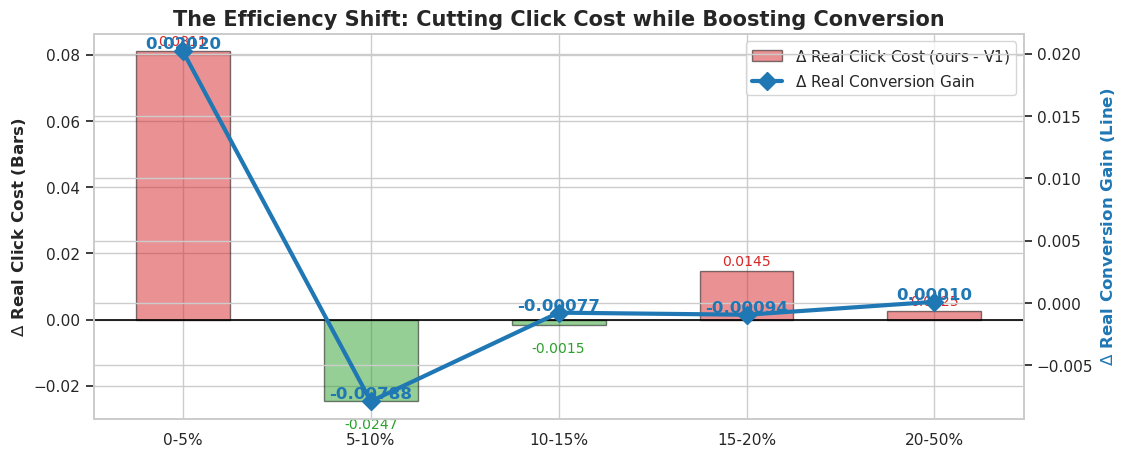

In [ ]:
# ==========================================
# 3. 启动执行模块
# ==========================================
if __name__ == "__main__":
    # 配置绝对真实的路径
    C_PATH  = "./results/criteo/train_c/TARNET/c_v1_base/**/test_dist.csv"
    V1_PATH = "./results/criteo/train_y/TARNET/y_v1_base/**/test_dist.csv"
    ours_PATH = "./results/criteo/train_y/MTMT/**/**/test_dist.csv" 
    
    analyzer = CausalSwappingAnalyzer(C_PATH, V1_PATH, ours_PATH)
    
    # 细致切割冲突区
    bins = [(0.0, 0.05), (0.05, 0.10), (0.10, 0.15), (0.15, 0.20), (0.20, 0.50)]
    results = [analyzer.analyze_swapping(s, e) for s, e in bins]
    df_report = pd.DataFrame(results)
    
    # 终端打印排版 (防乱码、防换行)
    pd.set_option('display.unicode.east_asian_width', True) 
    pd.set_option('display.unicode.ambiguous_as_wide', True)
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', 1500)
    pd.set_option('display.float_format', '{:.5f}'.format)
    
    print("\n" + "="*160)
    print("🏆 [换血对账单] ours vs V1_base 全景透视 (包含真实C与预测C)")
    print("="*160)
    # 按逻辑分组显示，一目了然
    display_cols = [
        '区间', '换血量', '🚨净Y收益', '净C代价',
        'ours_Y增益', 'V1_Y增益', 
        'ours_真实C', 'V1_真实C', 
        'ours_预测C', 'V1_预测C',
        'ours_因果效率', 'V1_因果效率'
    ]
    print(df_report[display_cols].to_string(index=False))
    print("="*160)
    
    # 生成图表
    plot_academic_swapping(df_report)